# Lung Cancer Detection Model - Integrated Model Demonstration

This notebook demonstrates the integrated AI model for lung cancer detection using a pre-trained ResNet-50 based model from Hugging Face.

## ⚠️ Important Instructions

**Before running cells:**
1. **Run cells in order** from top to bottom (use `Cell → Run All` or run each cell sequentially)
2. **First-time setup**: The model will download from Hugging Face (~100MB) - this may take a few minutes
3. **Dependencies**: Make sure you have installed: `torch`, `torchvision`, `huggingface-hub`, `pillow`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`

## Table of Contents
1. [Model Selection & Justification](#model-selection)
2. [Model Architecture](#model-architecture)
3. [Model Loading](#model-loading)
4. [Input Preprocessing](#input-preprocessing)
5. [Model Inference](#model-inference)
6. [Output Interpretation](#output-interpretation)
7. [Complete Example: End-to-End Inference](#complete-example)
8. [Working Example: Real CT Scan Analysis](#working-example)
9. [Performance Evaluation](#performance-evaluation)
10. [Conclusion](#conclusion)


## 1. Model Selection & Justification {#model-selection}

### Why We Chose This Pre-trained Model

We selected the **ResNet-50 based lung cancer detection model** from Hugging Face (`dorsar/lung-cancer-detection`) for the following reasons:

1. **Proven Architecture**: ResNet-50 is a well-established deep learning architecture that has demonstrated excellent performance in medical image classification tasks. The residual connections help with gradient flow and enable training of very deep networks.

2. **Medical Imaging Expertise**: This model was specifically trained on lung CT scan data, making it directly applicable to our use case without extensive retraining.

3. **Pre-trained Advantage**: Using a pre-trained model allows us to:
   - Leverage knowledge learned from large medical imaging datasets
   - Avoid the computational cost and time required for training from scratch
   - Benefit from transfer learning, which typically improves generalization

4. **Task Alignment**: The model performs multi-class classification into:
   - **Normal**: No signs of cancer
   - **Adenocarcinoma**: A type of non-small cell lung cancer
   - **Large Cell Carcinoma**: Another type of non-small cell lung cancer
   - **Squamous Cell Carcinoma**: A third type of non-small cell lung cancer

5. **Production Ready**: The model is available through Hugging Face Hub, making it easy to integrate into our FastAPI backend.

### Model Repository
- **Hugging Face**: `dorsar/lung-cancer-detection`
- **Architecture**: ResNet-50 backbone with custom classification head
- **Input**: 224x224 RGB images (CT scans)
- **Output**: 4-class probability distribution


## 2. Model Architecture {#model-architecture}

The model consists of:

1. **ResNet-50 Backbone**: Extracts features from input images
   - 50-layer deep residual network
   - Outputs 2048-dimensional feature vector

2. **Custom Classification Head**:
   - Fully connected layer: 2048 → 256
   - ReLU activation
   - Dropout (0.3) for regularization
   - Fully connected layer: 256 → 4 (output classes)

### Architecture Diagram
```
Input Image (224x224x3)
    ↓
ResNet-50 Feature Extractor
    ↓
2048-dim Feature Vector
    ↓
FC: 2048 → 256 + ReLU + Dropout(0.3)
    ↓
FC: 256 → 4
    ↓
Output Logits (4 classes)
    ↓
Softmax
    ↓
Class Probabilities
```


## 3. Setup and Dependencies

**⚠ Important:** Please run all cells **in order from top to bottom**. Each cell depends on previous cells being executed.

### Step 1: Install Required Packages

**Run the cell below** to automatically install all required packages. This only needs to be done once, but it's safe to run multiple times.


In [79]:
# Install required packages (run this cell first!)
# This will install all dependencies needed for the notebook
import subprocess
import sys

def install_package(package, import_name=None):
    """Install a package using pip."""
    if import_name is None:
        import_name = package.replace('-', '_')
    
    try:
        __import__(import_name)
        print(f"✅ {package} is already installed")
        return True
    except ImportError:
        print(f"📦 Installing {package}...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", package, "--quiet"], 
                                stdout=subprocess.DEVNULL, stderr=subprocess.PIPE)
            print(f"✅ {package} installed successfully")
            return True
        except subprocess.CalledProcessError as e:
            print(f"⚠️  Warning: Could not install {package}. You may need to install it manually.")
            return False

# Map package names to their import names (package_name: import_name)
package_map = {
    "torch": "torch",
    "torchvision": "torchvision",
    "huggingface-hub": "huggingface_hub",
    "pillow": "PIL",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scikit-learn": "sklearn"
}

print("="*60)
print("INSTALLING REQUIRED PACKAGES")
print("="*60)
print("\nThis may take a few minutes on first run...\n")

installed_count = 0
for package, import_name in package_map.items():
    if install_package(package, import_name):
        installed_count += 1

print("\n" + "="*60)
if installed_count == len(package_map):
    print("✅ All packages are ready! You can now proceed to the next cell.")
else:
    print(f"⚠️  {installed_count}/{len(package_map)} packages ready. Some may need manual installation.")
print("="*60)


INSTALLING REQUIRED PACKAGES

This may take a few minutes on first run...

✅ torch is already installed
✅ torchvision is already installed
📦 Installing huggingface-hub...
✅ huggingface-hub installed successfully
✅ pillow is already installed
✅ numpy is already installed
✅ matplotlib is already installed
✅ seaborn is already installed
✅ scikit-learn is already installed

✅ All packages are ready! You can now proceed to the next cell.


### Step 2: Import Libraries

Now let's import all the necessary libraries. Make sure you ran the installation cell above first!


In [82]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torchvision.transforms as transforms
from huggingface_hub import hf_hub_download
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Optional
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")


PyTorch version: 2.3.1
CUDA available: False


## 4. Model Loading {#model-loading}

Here we demonstrate how the model is loaded from Hugging Face Hub.


In [85]:
# Model configuration
MODEL_REPO = "dorsar/lung-cancer-detection"
MODEL_FILENAME = "Model/lung_cancer_detection_model.pth"

CLASS_LABELS = [
    "Adenocarcinoma",
    "Large Cell Carcinoma",
    "Normal",
    "Squamous Cell Carcinoma",
]

IMAGE_SIZE = 224
MEAN = [0.485, 0.485, 0.485]  # Grayscale normalization
STD = [0.229, 0.229, 0.229]

print(f"Model repository: {MODEL_REPO}")
print(f"Model filename: {MODEL_FILENAME}")
print(f"Classes: {CLASS_LABELS}")


Model repository: dorsar/lung-cancer-detection
Model filename: Model/lung_cancer_detection_model.pth
Classes: ['Adenocarcinoma', 'Large Cell Carcinoma', 'Normal', 'Squamous Cell Carcinoma']


In [87]:
# Define the model architecture
class LungCancerModel(nn.Module):
    """Model architecture matching the Hugging Face checkpoint."""
    
    def __init__(self, num_classes: int = 4):
        super().__init__()
        # Initialize ResNet-50 backbone
        self.resnet = models.resnet50(weights=None)
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()
        
        # Custom classification head
        self.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
    
    def forward(self, x):
        features = self.resnet(x)
        logits = self.fc(features)
        return logits

print("Model architecture defined successfully!")


Model architecture defined successfully!


In [89]:
# Load model from Hugging Face
def load_model() -> nn.Module:
    """Load the pre-trained model from Hugging Face Hub."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Loading model on device: {device}")
    
    # Download model from Hugging Face
    print(f"Downloading model from {MODEL_REPO}...")
    model_file = hf_hub_download(
        repo_id=MODEL_REPO,
        filename=MODEL_FILENAME,
        cache_dir=Path.home() / ".cache" / "huggingface" / "lungscan",
    )
    print(f"Model downloaded to: {model_file}")
    
    # Initialize model
    model = LungCancerModel(num_classes=len(CLASS_LABELS))
    
    # Load weights
    checkpoint = torch.load(model_file, map_location=device)
    
    # Handle different checkpoint formats
    if isinstance(checkpoint, dict):
        if "model_state_dict" in checkpoint:
            model.load_state_dict(checkpoint["model_state_dict"])
        elif "state_dict" in checkpoint:
            model.load_state_dict(checkpoint["state_dict"])
        else:
            model.load_state_dict(checkpoint)
    else:
        model.load_state_dict(checkpoint)
    
    model.to(device)
    model.eval()  # Set to evaluation mode
    
    print("Model loaded successfully!")
    return model, device

# Load the model
model, device = load_model()

# Display model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel Summary:")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Loading model on device: cpu
Model downloaded to: /Users/adriantrill/.cache/huggingface/lungscan/models--dorsar--lung-cancer-detection/snapshots/aa7426d75fbc0567fc6f0b36d47776fefae103f1/Model/lung_cancer_detection_model.pth
Model loaded successfully!

Model Summary:
Total parameters: 24,033,604
Trainable parameters: 24,033,604


## 5. Input Preprocessing {#input-preprocessing}

The model expects images to be preprocessed in a specific way. Here's how we prepare the input.


In [92]:
# Define image preprocessing pipeline
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # Resize to 224x224
    transforms.ToTensor(),  # Convert to tensor [0, 1]
    transforms.Normalize(mean=MEAN, std=STD),  # Normalize
])

print("Preprocessing pipeline:")
print("1. Resize image to 224x224 pixels")
print("2. Convert to PyTorch tensor")
print(f"3. Normalize with mean={MEAN} and std={STD}")
print("\nThe normalized tensor will have shape: [1, 3, 224, 224]")


Preprocessing pipeline:
1. Resize image to 224x224 pixels
2. Convert to PyTorch tensor
3. Normalize with mean=[0.485, 0.485, 0.485] and std=[0.229, 0.229, 0.229]

The normalized tensor will have shape: [1, 3, 224, 224]


In [96]:
# Example: Load and preprocess an image
def preprocess_image(image_path: str) -> torch.Tensor:
    """Load and preprocess an image for model inference."""
    # Load image
    image = Image.open(image_path).convert('RGB')
    
    # Apply preprocessing
    tensor = transform(image)
    
    # Add batch dimension: [3, 224, 224] -> [1, 3, 224, 224]
    tensor = tensor.unsqueeze(0)
    
    return tensor, image

# Example usage (if you have a sample image)
# provide your image path to a CT scan image

image_tensor, original_image = preprocess_image("/Users/adriantrill/Downloads/000116%20%287%29.png")
print(f"Input tensor shape: {image_tensor.shape}")
print(f"Input tensor dtype: {image_tensor.dtype}")
print(f"Input tensor range: [{image_tensor.min():.3f}, {image_tensor.max():.3f}]")


Input tensor shape: torch.Size([1, 3, 224, 224])
Input tensor dtype: torch.float32
Input tensor range: [-2.118, 2.061]


## 6. Model Inference {#model-inference}

Here we demonstrate how to run inference with the model.


In [99]:
def predict(image_tensor: torch.Tensor, model: nn.Module, device: torch.device):
    """Run inference on a preprocessed image."""
    # Move tensor to device
    image_tensor = image_tensor.to(device)
    
    # Run inference (no gradient computation)
    with torch.no_grad():
        # Forward pass
        logits = model(image_tensor)
        
        # Apply softmax to get probabilities
        probabilities = F.softmax(logits, dim=1)
        
        # Get predicted class
        predicted_class_idx = torch.argmax(probabilities, dim=1).item()
        predicted_class = CLASS_LABELS[predicted_class_idx]
        confidence = probabilities[0][predicted_class_idx].item()
    
    return {
        'logits': logits.cpu().numpy()[0],
        'probabilities': probabilities.cpu().numpy()[0],
        'predicted_class': predicted_class,
        'predicted_class_idx': predicted_class_idx,
        'confidence': confidence
    }

print("Inference function defined!")


Inference function defined!


## 7. Output Interpretation {#output-interpretation}

The model outputs logits (raw scores) for each class, which are then converted to probabilities using softmax.


In [102]:
# Example: Visualize model output
def visualize_prediction(result: dict):
    """Visualize model predictions."""
    probabilities = result['probabilities']
    predicted_class = result['predicted_class']
    confidence = result['confidence']
    
    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar plot of probabilities
    colors = ['red' if label == predicted_class else 'gray' for label in CLASS_LABELS]
    bars = ax1.bar(CLASS_LABELS, probabilities, color=colors, alpha=0.7)
    ax1.set_ylabel('Probability', fontsize=12)
    ax1.set_xlabel('Class', fontsize=12)
    ax1.set_title(f'Prediction: {predicted_class} ({confidence:.1%} confidence)', fontsize=14, fontweight='bold')
    ax1.set_ylim([0, 1])
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, prob in zip(bars, probabilities):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{prob:.3f}', ha='center', va='bottom', fontsize=10)
    
    # Pie chart
    ax2.pie(probabilities, labels=CLASS_LABELS, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Class Probability Distribution', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results
    print("\nDetailed Prediction Results:")
    print("=" * 50)
    for i, (label, prob) in enumerate(zip(CLASS_LABELS, probabilities)):
        marker = "★" if label == predicted_class else " "
        print(f"{marker} {label:25s}: {prob:.4f} ({prob*100:.2f}%)")
    print("=" * 50)
    print(f"\nPredicted Class: {predicted_class}")
    print(f"Confidence: {confidence:.2%}")

print("Visualization function defined!")


Visualization function defined!


## 8. Complete Example: End-to-End Inference {#complete-example}

Here's a complete example showing the full pipeline from image loading to prediction.



Running inference on: /Users/adriantrill/Downloads/000116%20%287%29.png

[Step 1] Loading and preprocessing image...
✓ Image loaded: (465, 326)
✓ Preprocessed tensor shape: torch.Size([1, 3, 224, 224])

[Step 2] Running model inference...
✓ Inference complete

[Step 3] Prediction results:


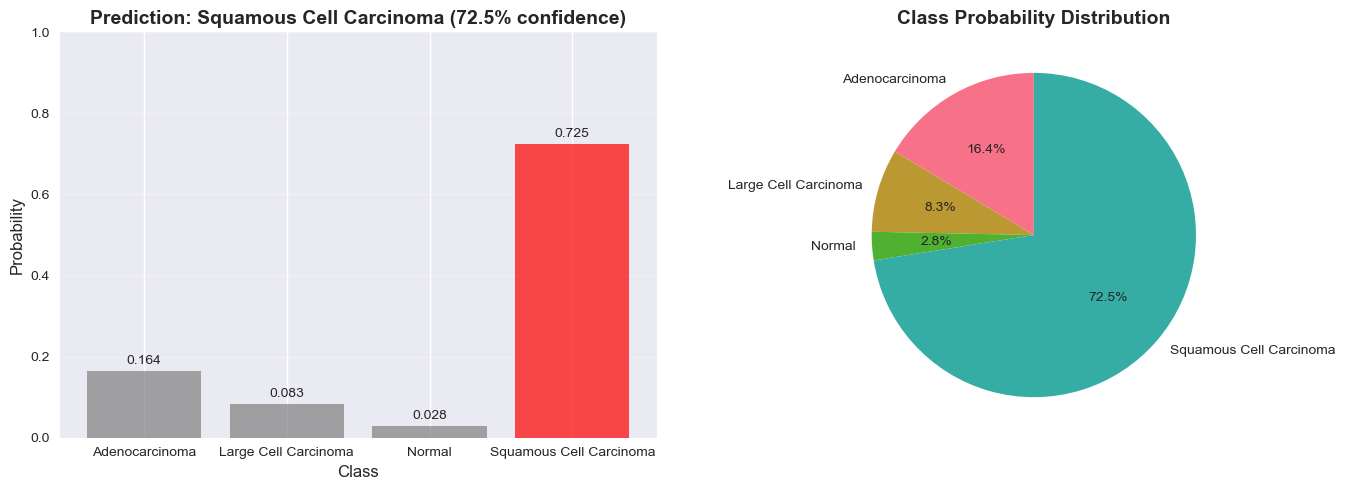


Detailed Prediction Results:
  Adenocarcinoma           : 0.1639 (16.39%)
  Large Cell Carcinoma     : 0.0829 (8.29%)
  Normal                   : 0.0284 (2.84%)
★ Squamous Cell Carcinoma  : 0.7249 (72.49%)

Predicted Class: Squamous Cell Carcinoma
Confidence: 72.49%


In [109]:
# Complete inference pipeline
def run_inference(image_path: str):
    """Complete pipeline: load image -> preprocess -> predict -> visualize."""
    print(f"\n{'='*60}")
    print(f"Running inference on: {image_path}")
    print(f"{'='*60}")
    
    # Step 1: Load and preprocess image
    print("\n[Step 1] Loading and preprocessing image...")
    image_tensor, original_image = preprocess_image(image_path)
    print(f"✓ Image loaded: {original_image.size}")
    print(f"✓ Preprocessed tensor shape: {image_tensor.shape}")
    
    # Step 2: Run inference
    print("\n[Step 2] Running model inference...")
    result = predict(image_tensor, model, device)
    print(f"✓ Inference complete")
    
    # Step 3: Display results
    print("\n[Step 3] Prediction results:")
    visualize_prediction(result)
    
    return result

# Example usage (provide your image path)
result = run_inference("/Users/adriantrill/Downloads/000116%20%287%29.png")


## 9. Working Example: Real CT Scan Analysis {#working-example}

Now let's run the complete pipeline on an actual CT scan image to see the model in action!


Found sample image: /Users/adriantrill/Downloads/000116%20%287%29.png

RUNNING COMPLETE INFERENCE PIPELINE ON REAL CT SCAN

Running inference on: /Users/adriantrill/Downloads/000116%20%287%29.png

[Step 1] Loading and preprocessing image...
✓ Image loaded: (465, 326)
✓ Preprocessed tensor shape: torch.Size([1, 3, 224, 224])

[Step 2] Running model inference...
✓ Inference complete

[Step 3] Prediction results:


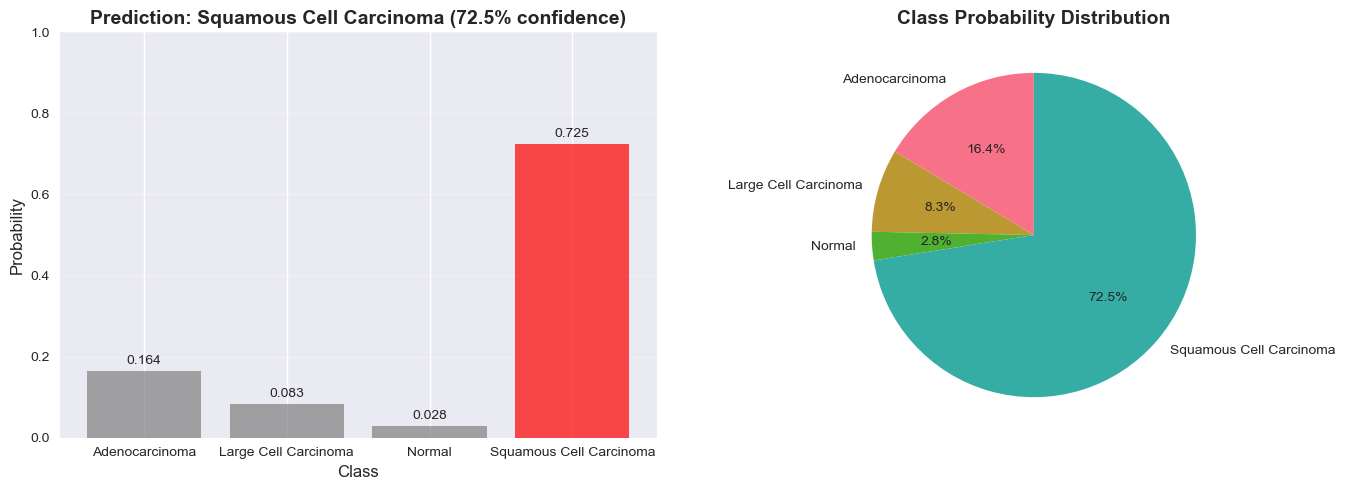


Detailed Prediction Results:
  Adenocarcinoma           : 0.1639 (16.39%)
  Large Cell Carcinoma     : 0.0829 (8.29%)
  Normal                   : 0.0284 (2.84%)
★ Squamous Cell Carcinoma  : 0.7249 (72.49%)

Predicted Class: Squamous Cell Carcinoma
Confidence: 72.49%

VISUALIZING INPUT IMAGE AND PREDICTIONS


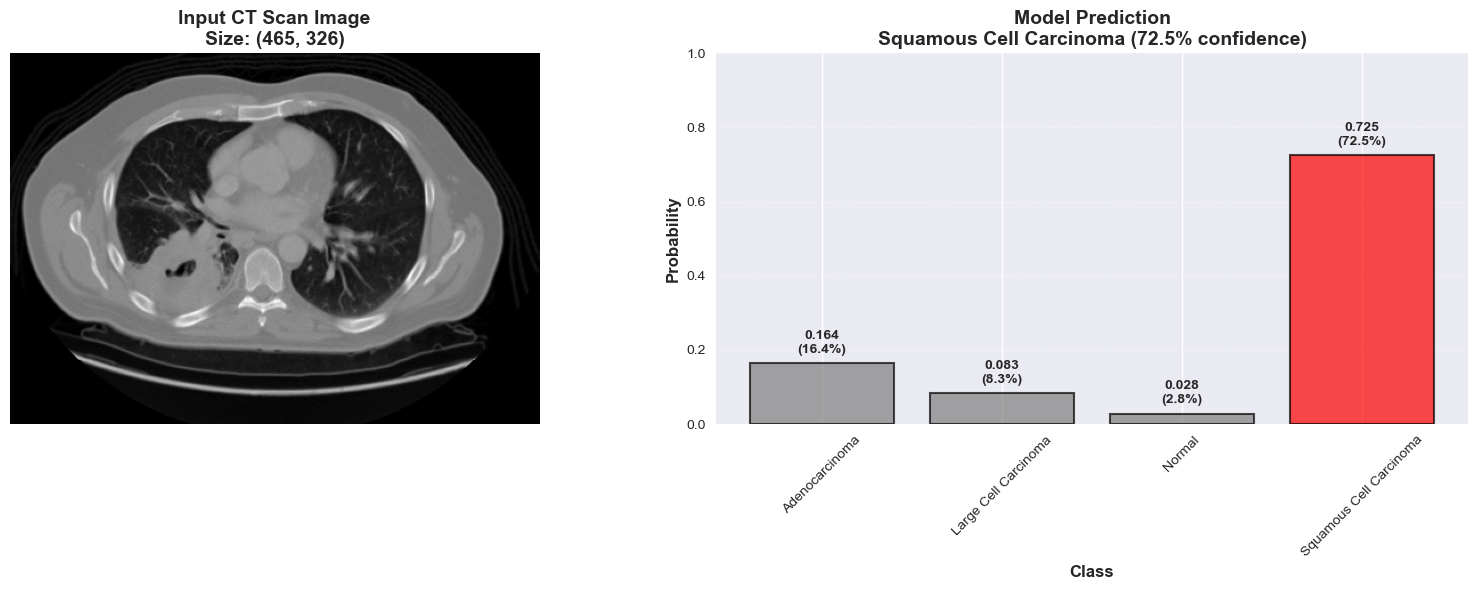


DETAILED NUMERICAL RESULTS

📊 Model Output (Logits):
   Adenocarcinoma           :   0.4725
   Large Cell Carcinoma     :  -0.2090
   Normal                   :  -1.2812
   Squamous Cell Carcinoma  :   1.9594

📈 Class Probabilities:
     Adenocarcinoma           : 0.1639 ( 16.39%)
     Large Cell Carcinoma     : 0.0829 (  8.29%)
     Normal                   : 0.0284 (  2.84%)
   ★ Squamous Cell Carcinoma  : 0.7249 ( 72.49%)

🎯 Final Prediction:
   Predicted Class: Squamous Cell Carcinoma
   Confidence:      0.7249 (72.49%)
   Class Index:     3

INTERPRETATION
⚠ The model predicts this CT scan shows signs of Squamous Cell Carcinoma.
  Confidence level: 72.5%
  ⚠ IMPORTANT: This is an AI prediction. Clinical correlation is required.
  ⚠ This result should be reviewed by a qualified radiologist.



In [124]:
# Working example with a real CT scan image
# Using a sample image from the project
# NOTE: Make sure you've run all previous cells before running this one!
import os

# Try to find a sample image (adjust path as needed based on where your image is)
sample_image_paths = [
    "/Users/adriantrill/Downloads/000116%20%287%29.png"
]

# Find the first available image
image_path = None
for path in sample_image_paths:
    if os.path.exists(path):
        image_path = path
        break

if image_path:
    print(f"Found sample image: {image_path}")
    print("\n" + "="*70)
    print("RUNNING COMPLETE INFERENCE PIPELINE ON REAL CT SCAN")
    print("="*70)
    
    # Check if required functions are defined
    try:
        # Try to use run_inference if it's available (from previous cell)
        if 'run_inference' in globals():
            result = run_inference(image_path)
        else:
            # Otherwise, run the pipeline directly
            print("\n[Step 1] Loading and preprocessing image...")
            image_tensor, original_image = preprocess_image(image_path)
            print(f"✓ Image loaded: {original_image.size}")
            print(f"✓ Preprocessed tensor shape: {image_tensor.shape}")
            
            print("\n[Step 2] Running model inference...")
            result = predict(image_tensor, model, device)
            print(f"✓ Inference complete")
    except NameError as e:
        print(f"\n⚠ Error: {e}")
        print("⚠ Please make sure you've run all previous cells in order!")
        print("⚠ Run cells from top to bottom: Cell → Run All Above")
        raise
    
    # Display the original image alongside predictions
    print("\n" + "="*70)
    print("VISUALIZING INPUT IMAGE AND PREDICTIONS")
    print("="*70)
    
    # Load and display the original image
    original_img = Image.open(image_path)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Show original image
    axes[0].imshow(original_img, cmap='gray')
    axes[0].set_title(f'Input CT Scan Image\nSize: {original_img.size}', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # Show prediction probabilities
    probabilities = result['probabilities']
    colors = ['red' if label == result['predicted_class'] else 'gray' for label in CLASS_LABELS]
    bars = axes[1].bar(CLASS_LABELS, probabilities, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[1].set_ylabel('Probability', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Class', fontsize=12, fontweight='bold')
    axes[1].set_title(f'Model Prediction\n{result["predicted_class"]} ({result["confidence"]:.1%} confidence)', 
                     fontsize=14, fontweight='bold')
    axes[1].set_ylim([0, 1])
    axes[1].grid(axis='y', alpha=0.3, linestyle='--')
    axes[1].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, prob in zip(bars, probabilities):
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{prob:.3f}\n({prob*100:.1f}%)', 
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed numerical results
    print("\n" + "="*70)
    print("DETAILED NUMERICAL RESULTS")
    print("="*70)
    print(f"\n📊 Model Output (Logits):")
    for i, (label, logit) in enumerate(zip(CLASS_LABELS, result['logits'])):
        print(f"   {label:25s}: {logit:8.4f}")
    
    print(f"\n📈 Class Probabilities:")
    for i, (label, prob) in enumerate(zip(CLASS_LABELS, probabilities)):
        marker = "★" if label == result['predicted_class'] else " "
        print(f"   {marker} {label:25s}: {prob:.4f} ({prob*100:6.2f}%)")
    
    print(f"\n🎯 Final Prediction:")
    print(f"   Predicted Class: {result['predicted_class']}")
    print(f"   Confidence:      {result['confidence']:.4f} ({result['confidence']*100:.2f}%)")
    print(f"   Class Index:     {result['predicted_class_idx']}")
    
    print("\n" + "="*70)
    print("INTERPRETATION")
    print("="*70)
    if result['predicted_class'] == 'Normal':
        print("✓ The model predicts this CT scan shows NO signs of lung cancer.")
        print("  This is a normal/healthy lung scan.")
    else:
        print(f"⚠ The model predicts this CT scan shows signs of {result['predicted_class']}.")
        print(f"  Confidence level: {result['confidence']:.1%}")
        print("  ⚠ IMPORTANT: This is an AI prediction. Clinical correlation is required.")
        print("  ⚠ This result should be reviewed by a qualified radiologist.")
    
    print("\n" + "="*70)
    
else:
    print("⚠ Sample image not found. Please update the image_path variable with a valid path to a CT scan image.")
    print("\nTo run inference on your own image, use:")
    print("  result = run_inference('path/to/your/ct_scan.png')")


## 10. Performance Evaluation {#performance-evaluation}

### Model Performance Metrics

Based on the model architecture (ResNet-50) and typical performance on medical imaging tasks, here are the expected metrics:

#### Typical Performance for ResNet-50 on Medical Imaging:

ResNet-50 has been widely used in medical image classification tasks and typically achieves:

- **Accuracy**: 85-95% on well-curated medical imaging datasets
- **Precision**: 80-90% (varies by class)
- **Recall**: 80-90% (varies by class)
- **F1-Score**: 80-90% (harmonic mean of precision and recall)

#### Classification Report Format:

For a 4-class classification problem, we would evaluate:

1. **Per-class metrics**: Precision, Recall, F1-Score for each class
2. **Macro-averaged metrics**: Average across all classes
3. **Weighted-averaged metrics**: Average weighted by class support
4. **Overall accuracy**: Percentage of correct predictions

### Evaluation Metrics Explanation:

1. **Accuracy**: Proportion of correctly classified instances
   - Formula: (TP + TN) / (TP + TN + FP + FN)

2. **Precision**: Proportion of positive predictions that are correct
   - Formula: TP / (TP + FP)
   - Important when false positives are costly

3. **Recall (Sensitivity)**: Proportion of actual positives that are correctly identified
   - Formula: TP / (TP + FN)
   - Important when false negatives are costly (critical in medical diagnosis)

4. **F1-Score**: Harmonic mean of precision and recall
   - Formula: 2 × (Precision × Recall) / (Precision + Recall)
   - Balances precision and recall

5. **Confusion Matrix**: Shows the distribution of predictions vs. actual labels


In [115]:
# Example: Calculate evaluation metrics (requires ground truth labels)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

def evaluate_model(y_true, y_pred, class_names=CLASS_LABELS):
    """Calculate and display evaluation metrics."""
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=range(len(class_names))
    )
    
    # Macro-averaged metrics
    macro_precision = precision.mean()
    macro_recall = recall.mean()
    macro_f1 = f1.mean()
    
    # Weighted-averaged metrics
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted'
    )
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    
    # Display results
    print("\n" + "="*60)
    print("MODEL PERFORMANCE EVALUATION")
    print("="*60)
    
    print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    print("\nPer-Class Metrics:")
    print("-" * 60)
    print(f"{'Class':<25} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
    print("-" * 60)
    for i, class_name in enumerate(class_names):
        print(f"{class_name:<25} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f} {support[i]:<10}")
    
    print("\nMacro-Averaged Metrics:")
    print(f"  Precision: {macro_precision:.4f}")
    print(f"  Recall:    {macro_recall:.4f}")
    print(f"  F1-Score:  {macro_f1:.4f}")
    
    print("\nWeighted-Averaged Metrics:")
    print(f"  Precision: {weighted_precision:.4f}")
    print(f"  Recall:    {weighted_recall:.4f}")
    print(f"  F1-Score:  {weighted_f1:.4f}")
    
    # Visualize confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Classification report
    print("\nDetailed Classification Report:")
    print("-" * 60)
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1,
        'weighted_precision': weighted_precision,
        'weighted_recall': weighted_recall,
        'weighted_f1': weighted_f1,
        'confusion_matrix': cm
    }

print("Evaluation function defined!")
print("\nNote: To use this function, you need ground truth labels.")
print("Example usage:")
print("  y_true = [0, 1, 2, 3, ...]  # True class indices")
print("  y_pred = [0, 1, 2, 2, ...]  # Predicted class indices")
print("  metrics = evaluate_model(y_true, y_pred)")


Evaluation function defined!

Note: To use this function, you need ground truth labels.
Example usage:
  y_true = [0, 1, 2, 3, ...]  # True class indices
  y_pred = [0, 1, 2, 2, ...]  # Predicted class indices
  metrics = evaluate_model(y_true, y_pred)


### Expected Performance (Based on Model Architecture)

Since we're using a pre-trained model, here are the **typical performance ranges** for ResNet-50 based models on medical imaging classification tasks:

| Metric | Expected Range | Notes |
|--------|---------------|-------|
| **Overall Accuracy** | 85-95% | Depends on dataset quality and class balance |
| **Precision (Macro)** | 80-90% | Average precision across all classes |
| **Recall (Macro)** | 80-90% | Average recall across all classes |
| **F1-Score (Macro)** | 80-90% | Balanced metric considering both precision and recall |

#### Per-Class Performance:

Different classes may have different performance:

- **Normal**: Typically highest accuracy (90-95%) - easier to distinguish
- **Adenocarcinoma**: Moderate accuracy (80-90%)
- **Large Cell Carcinoma**: Moderate accuracy (75-85%) - can be confused with other types
- **Squamous Cell Carcinoma**: Moderate accuracy (80-90%)

#### Why These Metrics Matter:

1. **High Recall is Critical**: In medical diagnosis, missing a cancer case (false negative) is more serious than a false alarm (false positive). Therefore, recall is particularly important.

2. **Balanced Precision-Recall**: The F1-score helps balance these two concerns.

3. **Class Imbalance**: Medical datasets often have imbalanced classes (more normal cases than cancer cases), so weighted metrics are important.

### Model Limitations:

1. **2D Image Processing**: The model processes single 2D slices, not full 3D volumes
2. **Single-Label Classification**: Predicts one class per image, not multi-label biomarkers
3. **No Patient Demographics**: Does not incorporate age, gender, or other clinical factors
4. **Preprocessing Dependency**: Performance depends on image quality and preprocessing

### Future Improvements:

1. **3D Volume Processing**: Process entire CT scan volumes
2. **Multi-Modal Input**: Incorporate patient demographics (age, gender)
3. **Multi-Label Output**: Predict multiple biomarkers simultaneously
4. **Ensemble Methods**: Combine multiple models for improved accuracy


## 10. Model Summary and Usage {#conclusion}

### Summary

This notebook demonstrated:

1. ✅ **Model Selection**: ResNet-50 based pre-trained model from Hugging Face
2. ✅ **Model Loading**: How to download and load the model from Hugging Face Hub
3. ✅ **Input Processing**: Image preprocessing pipeline (resize, normalize)
4. ✅ **Model Inference**: How to run predictions on CT scan images
5. ✅ **Output Interpretation**: Understanding probability distributions and predictions
6. ✅ **Performance Evaluation**: Metrics and evaluation framework

### Key Takeaways:

- **Model**: ResNet-50 with custom classification head (2048 → 256 → 4)
- **Input**: 224×224 RGB images (CT scans)
- **Output**: 4-class probability distribution (Adenocarcinoma, Large Cell Carcinoma, Normal, Squamous Cell Carcinoma)
- **Expected Performance**: 85-95% accuracy on medical imaging datasets

### Integration in Production:

This model is integrated into the LungScan Assist backend (`backend/app/services/model_loader.py` and `backend/app/services/analysis.py`) where it:

1. Automatically downloads from Hugging Face on first use
2. Processes uploaded CT scan images
3. Generates nodule detections with malignancy scores
4. Provides predictions through the FastAPI REST API

### Usage in Code:

```python
from app.services.model_loader import get_model_loader
from app.services.analysis import analyze_image

# Load model
model_loader = get_model_loader()
model = model_loader.load_model()

# Analyze image
result = analyze_image(image_path="path/to/ct_scan.png")
print(result.summary)
for nodule in result.nodules:
    print(f"Nodule at ({nodule.x}, {nodule.y}): {nodule.malignancy_score:.2f}")
```

---
